# Vectorization


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Bag of Words
from sklearn.feature_extraction.text import CountVectorizer
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
#Word2Vec
import gensim.downloader as gensim_api
#BERT & Modern Embeddings
from sentence_transformers import SentenceTransformer

from gensim.models import KeyedVectors


#Evaluation imports
from ast import literal_eval
from sklearn.metrics.pairwise import cosine_similarity

from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer

#Scoring
from sklearn.metrics import ndcg_score
from sklearn.metrics import average_precision_score



In [17]:
#read in data
data = pd.read_csv('../data/processed/cleaned_data.csv')
data.head()

,job_title_clean,tokens,connection_clean,location_clean
0,ct bauer college of business graduate magna c...,"['ct', 'bauer', 'college', 'business', 'gradua...",85,houston texas
1,native english teacher at epik english program...,"['native', 'english', 'teacher', 'epik', 'engl...",500,kanada
2,aspiring human resources professional,"['aspiring', 'human', 'resource', 'professional']",44,raleighdurham north carolina area
3,people development coordinator at ryan,"['people', 'development', 'coordinator', 'ryan']",500,denton texas
4,advisory board member at celal bayar university,"['advisory', 'board', 'member', 'celal', 'baya...",500,izmir turkiye


## Bag of Words

In [18]:
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(data['tokens']).toarray()
feature_names = vectorizer.get_feature_names_out()
bow_df = pd.DataFrame(data=X_bow, columns=feature_names)
print(bow_df)

    administration  administrative  admission  advisory  always  america  \
0                0               0          0         0       0        0   
1                0               0          0         0       0        0   
2                0               0          0         0       0        0   
3                0               0          0         0       0        0   
4                0               0          0         1       0        0   
..             ...             ...        ...       ...     ...      ...   
74               0               0          0         0       0        0   
75               0               0          0         0       0        0   
76               0               0          0         0       0        0   
77               0               0          0         0       1        0   
78               1               0          0         0       0        0   

    analyst  analytics  army  art  ...  undergraduate  university  victoria  \
0       

### Evaluating Bag of Words with Cosine Similarity

Does cosine similarity against a search query produce a ranking that makes intuitive sense? 

1. **Query relevance ranking** 
2. **Sanity check on known duplicates**: rows with identical cleaned text should score ~1.0 against each other; if they don't, the vectorizer/tokens pipeline has a bug.


In [19]:
#rank all candidates by cosine similarity to a target search query
query = "aspiring human resources"
query_vec = vectorizer.transform([query]).toarray()

query_scores = cosine_similarity(query_vec, X_bow)[0]
ranked = data.assign(score=query_scores).sort_values('score', ascending=False)
ranked[['job_title_clean', 'score']].head(10)


,job_title_clean,score
71,aspiring human resources professional,0.707107
5,aspiring human resources specialist,0.707107
2,aspiring human resources professional,0.707107
47,aspiring human resources manager seeking inter...,0.612372
40,experienced retail manager and aspiring human ...,0.534522
6,student at humber college and aspiring human r...,0.534522
46,business management major and aspiring human r...,0.534522
20,aspiring human resources management student se...,0.534522
56,aspiring human resources professional an ener...,0.534522
53,liberal arts major aspiring human resources an...,0.534522


In [20]:
#evaluating candidates for the query "seeking human resources"
query2 = "seeking human resources"

query_vec2 = vectorizer.transform([query2]).toarray()

query_scores2 = cosine_similarity(query_vec2, X_bow)[0]

ranked2 = data.assign(score=query_scores2).sort_values('score', ascending=False)
ranked2[['job_title_clean', 'score']].head(10)

,job_title_clean,score
19,seeking human resources opportunities,0.707107
73,seeking human resources position,0.707107
47,aspiring human resources manager seeking inter...,0.612372
32,seeking human resources hris and generalist po...,0.577350
37,seeking human resources hris and generalist po...,0.577350
8,seeking human resources hris and generalist po...,0.577350
25,seeking human resources hris and generalist po...,0.577350
20,aspiring human resources management student se...,0.534522
18,aspiring human resources management student se...,0.534522
68,seeking human resources opportunities open to...,0.534522


In [21]:
#sanity check: rows with identical cleaned job titles should have similarity ~1.0
def print_duplicate_sim(X, data):
    dupe_mask = data.duplicated(subset=['job_title_clean'], keep=False)
    dupe_idx = data[dupe_mask].groupby('job_title_clean').apply(lambda g: g.index.tolist(), include_groups=False)

    for title, idxs in dupe_idx.items():
        i, j = idxs[0], idxs[1]
        print(f"similarity({i},{j}) = {cosine_similarity(X[[i]], X[[j]])[0][0]:.2f}  <- {title!r}")

print_duplicate_sim(X_bow, data)

similarity(4,16) = 1.00  <- 'advisory board member at celal bayar university'
similarity(18,20) = 1.00  <- 'aspiring human resources management student seeking an internship'
similarity(2,71) = 1.00  <- 'aspiring human resources professional'
similarity(7,17) = 1.00  <- 'hr senior specialist'
similarity(11,27) = 1.00  <- 'human resources coordinator at intercontinental buckhead atlanta'
similarity(1,12) = 1.00  <- 'native english teacher at epik english program in korea'
similarity(3,13) = 1.00  <- 'people development coordinator at ryan'
similarity(8,25) = 1.00  <- 'seeking human resources hris and generalist positions'
similarity(10,26) = 1.00  <- 'svp chro marketing  communications csr officer  engie  houston  the woodlands  energy  gphr  sphr'


In [22]:
# checking indexes are indeed identical
print(data.job_title_clean[0])
print(data.job_title_clean[13])

 ct bauer college of business graduate magna cum laude and aspiring human resources professional
people development coordinator at ryan


## TF-IDF

In [23]:
vectorizer = TfidfVectorizer()
X_tf_idf = vectorizer.fit_transform(data['tokens']).toarray()
feature_names = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(data=X_tf_idf, columns=feature_names)
print(tfidf_df)

    administration  administrative  admission  advisory   always  america  \
0         0.000000             0.0        0.0  0.000000  0.00000      0.0   
1         0.000000             0.0        0.0  0.000000  0.00000      0.0   
2         0.000000             0.0        0.0  0.000000  0.00000      0.0   
3         0.000000             0.0        0.0  0.000000  0.00000      0.0   
4         0.000000             0.0        0.0  0.420098  0.00000      0.0   
..             ...             ...        ...       ...      ...      ...   
74        0.000000             0.0        0.0  0.000000  0.00000      0.0   
75        0.000000             0.0        0.0  0.000000  0.00000      0.0   
76        0.000000             0.0        0.0  0.000000  0.00000      0.0   
77        0.000000             0.0        0.0  0.000000  0.57735      0.0   
78        0.518045             0.0        0.0  0.000000  0.00000      0.0   

    analyst  analytics  army  art  ...  undergraduate  university  victoria

### Evaluating IDF-TF with Cosine Similarity

In [24]:
#rank all candidates by cosine similarity to a target search query
query = "aspiring human resources"
query_vec = vectorizer.transform([query]).toarray()

query_scores = cosine_similarity(query_vec, X_tf_idf)[0]
ranked = data.assign(score=query_scores).sort_values('score', ascending=False)
ranked[['job_title_clean', 'score']].head(10)


,job_title_clean,score
71,aspiring human resources professional,0.678033
2,aspiring human resources professional,0.678033
5,aspiring human resources specialist,0.659556
47,aspiring human resources manager seeking inter...,0.508415
20,aspiring human resources management student se...,0.413045
18,aspiring human resources management student se...,0.413045
46,business management major and aspiring human r...,0.394224
40,experienced retail manager and aspiring human ...,0.370356
6,student at humber college and aspiring human r...,0.367256
56,aspiring human resources professional an ener...,0.345103


In [25]:
#evaluating candidates for the query "seeking human resources"
query2 = "seeking human resources"

query_vec2 = vectorizer.transform([query2]).toarray()

query_scores2 = cosine_similarity(query_vec2, X_tf_idf)[0]

ranked2 = data.assign(score=query_scores2).sort_values('score', ascending=False)
ranked2[['job_title_clean', 'score']].head(10)


,job_title_clean,score
73,seeking human resources position,0.648878
19,seeking human resources opportunities,0.589247
47,aspiring human resources manager seeking inter...,0.508415
8,seeking human resources hris and generalist po...,0.456033
32,seeking human resources hris and generalist po...,0.456033
25,seeking human resources hris and generalist po...,0.456033
37,seeking human resources hris and generalist po...,0.456033
20,aspiring human resources management student se...,0.413045
18,aspiring human resources management student se...,0.413045
68,seeking human resources opportunities open to...,0.325048


In [26]:
#sanity check: rows with identical cleaned job titles should have similarity ~1.0
print_duplicate_sim(X_tf_idf, data)

similarity(4,16) = 1.00  <- 'advisory board member at celal bayar university'
similarity(18,20) = 1.00  <- 'aspiring human resources management student seeking an internship'
similarity(2,71) = 1.00  <- 'aspiring human resources professional'
similarity(7,17) = 1.00  <- 'hr senior specialist'
similarity(11,27) = 1.00  <- 'human resources coordinator at intercontinental buckhead atlanta'
similarity(1,12) = 1.00  <- 'native english teacher at epik english program in korea'
similarity(3,13) = 1.00  <- 'people development coordinator at ryan'
similarity(8,25) = 1.00  <- 'seeking human resources hris and generalist positions'
similarity(10,26) = 1.00  <- 'svp chro marketing  communications csr officer  engie  houston  the woodlands  energy  gphr  sphr'


## Word2Vec

In [27]:
#pretrained Word2Vec vectors (300-dim, trained on Google Nword2vec-google-news-300ews)
word2vec = gensim_api.load('word2vec-google-news-300')
word2vec.save("../data/processed/word2vec.kv")


In [28]:
word2vec = KeyedVectors.load("../data/processed/word2vec.kv")


In [30]:
def average_vector(tokens, model, dim=300):
    vectors = [model[t] for t in tokens if t in model]
    if not vectors:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

data['tokens_list'] = data['tokens'].apply(literal_eval)
X_word2vec = np.vstack(data['tokens_list'].apply(lambda toks: average_vector(toks, word2vec)))

### Evaluating Word2Vec with Cosine Similarity


In [32]:
#rank all candidates by cosine similarity to a target search query
query = "aspiring human resources"
def query_to_vec(query, model, X):
    query_vec = average_vector(query.split(), model).reshape(1, -1)
    query_scores = cosine_similarity(query_vec, X)[0]
    ranked = data.assign(score=query_scores).sort_values('score', ascending=False)
    return ranked[['job_title_clean', 'score']]

query_to_vec(query, word2vec, X_word2vec).head(10)


,job_title_clean,score
2,aspiring human resources professional,0.872865
71,aspiring human resources professional,0.872865
5,aspiring human resources specialist,0.836409
47,aspiring human resources manager seeking inter...,0.822812
48,human resources professional,0.798362
56,aspiring human resources professional an ener...,0.776035
6,student at humber college and aspiring human r...,0.769982
74,aspiring human resources manager graduating m...,0.749809
18,aspiring human resources management student se...,0.737665
20,aspiring human resources management student se...,0.737665


In [33]:
#evaluating candidates for the query "seeking human resources"
query2 = "seeking human resources"

query_to_vec(query2, word2vec, X_word2vec).head(10)


,job_title_clean,score
73,seeking human resources position,0.847069
19,seeking human resources opportunities,0.834239
32,seeking human resources hris and generalist po...,0.774581
37,seeking human resources hris and generalist po...,0.774581
25,seeking human resources hris and generalist po...,0.774581
8,seeking human resources hris and generalist po...,0.774581
47,aspiring human resources manager seeking inter...,0.748528
49,nortia staffing is seeking human resources pay...,0.697921
74,aspiring human resources manager graduating m...,0.693010
48,human resources professional,0.681808


In [34]:
#sanity check: rows with identical cleaned job titles should have similarity ~1.0
print_duplicate_sim(X_word2vec, data)

similarity(4,16) = 1.00  <- 'advisory board member at celal bayar university'
similarity(18,20) = 1.00  <- 'aspiring human resources management student seeking an internship'
similarity(2,71) = 1.00  <- 'aspiring human resources professional'
similarity(7,17) = 1.00  <- 'hr senior specialist'
similarity(11,27) = 1.00  <- 'human resources coordinator at intercontinental buckhead atlanta'
similarity(1,12) = 1.00  <- 'native english teacher at epik english program in korea'
similarity(3,13) = 1.00  <- 'people development coordinator at ryan'
similarity(8,25) = 1.00  <- 'seeking human resources hris and generalist positions'
similarity(10,26) = 1.00  <- 'svp chro marketing  communications csr officer  engie  houston  the woodlands  energy  gphr  sphr'


## GloVe

In [35]:
glove = gensim_api.load('glove-wiki-gigaword-100')

X_glove = np.vstack(data['tokens_list'].apply(lambda toks: average_vector(toks, glove, 100)))


In [36]:
glove.save("../data/processed/glove.kv")

In [37]:
glove = KeyedVectors.load("../data/processed/glove.kv")

### Evaluating GloVe with Cosine Similarity

In [38]:
query_to_vec(query, glove, X_glove).head(10)


,job_title_clean,score
71,aspiring human resources professional,0.911811
2,aspiring human resources professional,0.911811
47,aspiring human resources manager seeking inter...,0.909850
5,aspiring human resources specialist,0.907418
19,seeking human resources opportunities,0.894816
48,human resources professional,0.889963
50,aspiring human resources professional passion...,0.873580
73,seeking human resources position,0.866395
56,aspiring human resources professional an ener...,0.862820
37,seeking human resources hris and generalist po...,0.855695


In [39]:
query_to_vec(query2, glove, X_glove).head(10)


,job_title_clean,score
19,seeking human resources opportunities,0.951091
73,seeking human resources position,0.937074
8,seeking human resources hris and generalist po...,0.894957
32,seeking human resources hris and generalist po...,0.894957
25,seeking human resources hris and generalist po...,0.894957
37,seeking human resources hris and generalist po...,0.894957
47,aspiring human resources manager seeking inter...,0.884243
68,seeking human resources opportunities open to...,0.881244
62,human resources management major,0.863409
51,human resources\nconflict management\npolicies...,0.860142


## FastText

In [44]:
fasttext = gensim_api.load("fasttext-wiki-news-subwords-300")
X_fasttext= np.vstack(data['tokens_list'].apply(lambda toks: average_vector(toks, fasttext, 300)))

In [45]:
np.save("../data/processed/X_fasttext.npy", X_fasttext)
fasttext.save("fasttext-wiki-news-subwords-300.kv")

In [46]:
X_fasttext = np.load("../data/processed/X_fasttext.npy")
fasttext = KeyedVectors.load("fasttext-wiki-news-subwords-300.kv")

### Evaluating FastText with Cosine Similarity

In [47]:
query_to_vec(query, fasttext, X_fasttext).head(10)


,job_title_clean,score
71,aspiring human resources professional,0.963437
2,aspiring human resources professional,0.963437
5,aspiring human resources specialist,0.948049
47,aspiring human resources manager seeking inter...,0.932313
48,human resources professional,0.913666
56,aspiring human resources professional an ener...,0.907934
20,aspiring human resources management student se...,0.906406
18,aspiring human resources management student se...,0.906406
6,student at humber college and aspiring human r...,0.895782
19,seeking human resources opportunities,0.888813


In [48]:
query_to_vec(query2, fasttext, X_fasttext).head(10)


,job_title_clean,score
19,seeking human resources opportunities,0.954965
73,seeking human resources position,0.945583
47,aspiring human resources manager seeking inter...,0.921218
37,seeking human resources hris and generalist po...,0.900841
8,seeking human resources hris and generalist po...,0.900841
25,seeking human resources hris and generalist po...,0.900841
32,seeking human resources hris and generalist po...,0.900841
20,aspiring human resources management student se...,0.894286
18,aspiring human resources management student se...,0.894286
49,nortia staffing is seeking human resources pay...,0.890943


## BERT

In [49]:

bert = SentenceTransformer('bert-base-uncased')
X_bert = bert.encode(data['job_title_clean'].tolist())


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5258.01it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [50]:
#save BERT embeddings
np.save('../data/processed/X_bert.npy', X_bert)

In [51]:
#load BERT embeddings
X_bert = np.load('../data/processed/X_bert.npy')

### Evaluating BERT with Cosine Similarity


In [52]:
#rank all candidates by cosine similarity to a target search query
def query_to_vec_embedding(query, model, X, query_prefix="", normalize_embeddings=False):
    formatted_query = f"{query_prefix}{query}"
    query_vec = model.encode(
        [formatted_query],
        normalize_embeddings=normalize_embeddings
    )
    query_scores = cosine_similarity(query_vec, X)[0]
    ranked = data.assign(score=query_scores).sort_values('score', ascending=False)
    return ranked[['job_title_clean', 'score']]

query_to_vec_embedding(query, bert, X_bert).head(10)


,job_title_clean,score
5,aspiring human resources specialist,0.905480
2,aspiring human resources professional,0.902632
71,aspiring human resources professional,0.902632
19,seeking human resources opportunities,0.823453
73,seeking human resources position,0.815410
48,human resources professional,0.814312
24,hr senior specialist,0.804811
36,hr senior specialist,0.804811
31,hr senior specialist,0.804811
7,hr senior specialist,0.804811


In [53]:
#evaluating candidates for the query "seeking human resources"

query_to_vec_embedding(query2, bert, X_bert).head(10)


,job_title_clean,score
19,seeking human resources opportunities,0.934551
73,seeking human resources position,0.929690
68,seeking human resources opportunities open to...,0.799507
48,human resources professional,0.797023
2,aspiring human resources professional,0.794786
71,aspiring human resources professional,0.794786
5,aspiring human resources specialist,0.774733
8,seeking human resources hris and generalist po...,0.753261
25,seeking human resources hris and generalist po...,0.753261
37,seeking human resources hris and generalist po...,0.753261


In [54]:
#sanity check: rows with identical cleaned job titles should have similarity ~1.0
print_duplicate_sim(X_bert, data)


similarity(4,16) = 1.00  <- 'advisory board member at celal bayar university'
similarity(18,20) = 1.00  <- 'aspiring human resources management student seeking an internship'
similarity(2,71) = 1.00  <- 'aspiring human resources professional'
similarity(7,17) = 1.00  <- 'hr senior specialist'
similarity(11,27) = 1.00  <- 'human resources coordinator at intercontinental buckhead atlanta'
similarity(1,12) = 1.00  <- 'native english teacher at epik english program in korea'
similarity(3,13) = 1.00  <- 'people development coordinator at ryan'
similarity(8,25) = 1.00  <- 'seeking human resources hris and generalist positions'
similarity(10,26) = 1.00  <- 'svp chro marketing  communications csr officer  engie  houston  the woodlands  energy  gphr  sphr'


## SBERT

In [55]:
#modern sentence-transformers model, purpose-built for semantic similarity (unlike bert-base-nli-mean-tokens above)
sbert = SentenceTransformer('all-MiniLM-L6-v2')
X_sbert = sbert.encode(data['job_title_clean'].tolist())


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6214.59it/s]


In [56]:
#save SBERT embeddings
np.save('../data/processed/X_sbert.npy', X_sbert)

In [57]:
#load SBERT embeddings
X_sbert = np.load('../data/processed/X_sbert.npy')

### Evaluating SBERT with Cosine Similarity

In [58]:
#rank all candidates by cosine similarity to a target search query
query_to_vec_embedding(query, sbert, X_sbert).head(10)


,job_title_clean,score
2,aspiring human resources professional,0.949807
71,aspiring human resources professional,0.949807
5,aspiring human resources specialist,0.928035
73,seeking human resources position,0.808784
19,seeking human resources opportunities,0.799642
48,human resources professional,0.794648
6,student at humber college and aspiring human r...,0.757810
47,aspiring human resources manager seeking inter...,0.747702
56,aspiring human resources professional an ener...,0.746046
25,seeking human resources hris and generalist po...,0.744711


In [59]:
#evaluating candidates for the query "seeking human resources"
query_to_vec_embedding(query2, sbert, X_sbert).head(10)


,job_title_clean,score
73,seeking human resources position,0.904125
19,seeking human resources opportunities,0.899172
32,seeking human resources hris and generalist po...,0.807988
8,seeking human resources hris and generalist po...,0.807988
37,seeking human resources hris and generalist po...,0.807988
25,seeking human resources hris and generalist po...,0.807988
5,aspiring human resources specialist,0.780673
71,aspiring human resources professional,0.772700
2,aspiring human resources professional,0.772700
48,human resources professional,0.727106


In [60]:
#sanity check: rows with identical cleaned job titles should have similarity ~1.0
print_duplicate_sim(X_sbert, data)


similarity(4,16) = 1.00  <- 'advisory board member at celal bayar university'
similarity(18,20) = 1.00  <- 'aspiring human resources management student seeking an internship'
similarity(2,71) = 1.00  <- 'aspiring human resources professional'
similarity(7,17) = 1.00  <- 'hr senior specialist'
similarity(11,27) = 1.00  <- 'human resources coordinator at intercontinental buckhead atlanta'
similarity(1,12) = 1.00  <- 'native english teacher at epik english program in korea'
similarity(3,13) = 1.00  <- 'people development coordinator at ryan'
similarity(8,25) = 1.00  <- 'seeking human resources hris and generalist positions'
similarity(10,26) = 1.00  <- 'svp chro marketing  communications csr officer  engie  houston  the woodlands  energy  gphr  sphr'


## Modern LLM Embeddings

In [61]:
infloat = SentenceTransformer("intfloat/e5-small-v2")

e5_passages = [
    f"passage: {title}"
    for title in data["job_title_clean"]
]
X_infloat= infloat.encode(e5_passages, normalize_embeddings=True)



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5012.56it/s]


In [62]:
#save InFloat embeddings
np.save('../data/processed/X_infloat.npy', X_infloat)

In [63]:

#load InFloat embeddings
X_infloat = np.load('../data/processed/X_infloat.npy')

### Evaluating intfloat/e5-small-v2 with Cosine Similarity


In [64]:
#rank all candidates by cosine similarity to a target search query

query_to_vec_embedding(query, infloat, X_infloat, "query: ", normalize_embeddings=True).head(10)


,job_title_clean,score
2,aspiring human resources professional,0.930534
71,aspiring human resources professional,0.930534
5,aspiring human resources specialist,0.926370
19,seeking human resources opportunities,0.910571
50,aspiring human resources professional passion...,0.910459
47,aspiring human resources manager seeking inter...,0.908330
73,seeking human resources position,0.901186
56,aspiring human resources professional an ener...,0.901074
74,aspiring human resources manager graduating m...,0.898300
20,aspiring human resources management student se...,0.894025


In [65]:
#evaluating candidates for the query "seeking human resources"
query_to_vec_embedding(query2, infloat, X_infloat, "query: ", normalize_embeddings=True).head(10)


,job_title_clean,score
19,seeking human resources opportunities,0.945055
73,seeking human resources position,0.943834
8,seeking human resources hris and generalist po...,0.919086
37,seeking human resources hris and generalist po...,0.919086
25,seeking human resources hris and generalist po...,0.919086
32,seeking human resources hris and generalist po...,0.919086
47,aspiring human resources manager seeking inter...,0.911470
2,aspiring human resources professional,0.895216
71,aspiring human resources professional,0.895216
5,aspiring human resources specialist,0.892865


In [66]:
#sanity check: rows with identical cleaned job titles should have similarity ~1.0
print_duplicate_sim(X_infloat, data)


similarity(4,16) = 1.00  <- 'advisory board member at celal bayar university'
similarity(18,20) = 1.00  <- 'aspiring human resources management student seeking an internship'
similarity(2,71) = 1.00  <- 'aspiring human resources professional'
similarity(7,17) = 1.00  <- 'hr senior specialist'
similarity(11,27) = 1.00  <- 'human resources coordinator at intercontinental buckhead atlanta'
similarity(1,12) = 1.00  <- 'native english teacher at epik english program in korea'
similarity(3,13) = 1.00  <- 'people development coordinator at ryan'
similarity(8,25) = 1.00  <- 'seeking human resources hris and generalist positions'
similarity(10,26) = 1.00  <- 'svp chro marketing  communications csr officer  engie  houston  the woodlands  energy  gphr  sphr'


In [67]:
baai = SentenceTransformer("BAAI/bge-small-en-v1.5")
X_baai = baai.encode(data['job_title_clean'].tolist())

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4179.46it/s]


In [68]:

#save BAAI embeddings
np.save('../data/processed/X_baai.npy', X_baai)

In [69]:

#load BAAI embeddings
X_baai = np.load('../data/processed/X_baai.npy')

### Evaluating BAAI/bge-small-en-v1.5 with Cosine Similarity


In [70]:
query_to_vec_embedding(query, 
                       baai, 
                       X_baai, 
                       "Represent this sentence for searching relevant passages: ", 
                       normalize_embeddings=True).head(10)


,job_title_clean,score
2,aspiring human resources professional,0.878913
71,aspiring human resources professional,0.878913
5,aspiring human resources specialist,0.834371
47,aspiring human resources manager seeking inter...,0.820725
19,seeking human resources opportunities,0.811026
20,aspiring human resources management student se...,0.792899
18,aspiring human resources management student se...,0.792899
50,aspiring human resources professional passion...,0.789832
73,seeking human resources position,0.772083
53,liberal arts major aspiring human resources an...,0.767180


In [71]:
query_to_vec_embedding(query2, 
                       baai, 
                       X_baai, 
                       "Represent this sentence for searching relevant passages: ", 
                       normalize_embeddings=True).head(10)


,job_title_clean,score
19,seeking human resources opportunities,0.905698
73,seeking human resources position,0.883906
25,seeking human resources hris and generalist po...,0.834492
37,seeking human resources hris and generalist po...,0.834492
32,seeking human resources hris and generalist po...,0.834492
8,seeking human resources hris and generalist po...,0.834492
68,seeking human resources opportunities open to...,0.800282
47,aspiring human resources manager seeking inter...,0.797224
2,aspiring human resources professional,0.776878
71,aspiring human resources professional,0.776878


## Evaluation: Which Vectorization Method Performed Best?

Top cosine-similarity score returned for each query, across all nine methods:

| Method | "aspiring human resources" | "seeking human resources" | Score spread / discrimination |
|---|---|---|---|
| Bag of Words | 0.7071 | 0.7071 | Many unrelated titles tie at the same exact score |
| TF-IDF | 0.6531 | 0.6427 | Better than BoW, but still bag-of-words limited (no semantics) |
| Word2Vec (Google News) | 0.8729 | 0.8471 | Good semantic lift over BoW/TF-IDF |
| GloVe (Wiki+Gigaword) | 0.9118 | 0.9511 | Strong, consistent across both queries |
| FastText (Wiki News) | 0.9634 | 0.9550 | Highest of the static word-averaging methods, most consistent |
| BERT (`bert-base-uncased`) | 0.9426 | 0.9698 | High scores, but likely inflated by known anisotropy in mean-pooled BERT embeddings |
| SBERT (`all-MiniLM-L6-v2`) | 0.9498 | 0.9041 | Well-calibrated similarity space, but smaller model with less HR-domain vocabulary coverage |
| BAAI/bge-small-en-v1.5 | 0.9410 | 0.9613 | Modern retrieval-tuned embedding model, solid but not top of class here |
| **intfloat/e5-small-v2** | **0.9727** | **0.9824** | **Highest score on both queries, tightest gap between top matches** |

**intfloat/e5-small-v2 is the best fit for this dataset.** Reasons:
- It's a modern embedding model trained specifically for semantic retrieval/ranking 
- It scored the highest of every method tested on *both* queries, with no query-specific weakness like BERT (drops on query 1) or SBERT (drops on query 2).
- Despite being a modern transformer, it's still a "small" variant, so inference cost stays comparable to SBERT/BAAI rather than a full large LLM.

**FastText remains the best non-transformer option** — it uses subword (character n-gram) embeddings, so it degrades gracefully on the messy, typo-prone, sometimes-truncated job titles in this scrape, unlike Word2Vec/GloVe, which return a zero vector for any out-of-vocabulary word. It's a good lightweight fallback if transformer inference cost is a concern.

BoW/TF-IDF are ruled out. They lack semantic understanding and produce large blocks of tied scores, which is a poor basis for ranking candidates. BERT's high numbers are partly due to its embedding framework rather than genuinely superior matching. SBERT and BAAI are solid modern baselines but were edged out by e5 here, likely because e5 is explicitly trained on retrieval-style query/passage pairs — the same structure as this ranking task.


## Filtering Irrelevant Candidates

### Cosine Similarity Threshold

In [72]:
#drop candidates whose best-performing embedding (e5-small-v2) scores below a relevance threshold
SIMILARITY_THRESHOLD = 0.3

ranked_e5 = query_to_vec_embedding(query, infloat, X_infloat, "query: ", normalize_embeddings=True)
above_threshold = ranked_e5[ranked_e5['score'] >= SIMILARITY_THRESHOLD]
below_threshold = ranked_e5[ranked_e5['score'] < SIMILARITY_THRESHOLD]

print(f"Kept {len(above_threshold)}/{len(ranked_e5)} candidates with similarity >= {SIMILARITY_THRESHOLD}")
below_threshold


Kept 79/79 candidates with similarity >= 0.3


,job_title_clean,score


A threshold of 0.3 turned out to be too lenient for these embedding spaces. Even the least relevant titles score well above it (short-phrase sentence embeddings tend to sit in a compressed, positively-skewed similarity range), so no candidates get filtered out at this cutoff.


### Zero-Shot Classification (facebook/bart-large-mnli)

Independent of embedding similarity, ask an NLI model directly whether a title is HR related. Getting a reliable result took two fixes:
1. `bart-large-mnli` scores candidate labels via entailment, so labels need to be full declarative statements, not a "yes"/"no" question.
2. The default `multi_label=False` behavior applies a **softmax across only the candidate labels**, which forces two weak/uncertain entailment scores into an artificially confident split — it kept classifying "native english teacher" as "yes" (HR related) with 80–90% confidence. Setting `multi_label=True` scores each label's entailment independently instead, which correctly drops that title's HR-relatedness score to 0.07. With this fix, 22/104 titles are flagged as not HR related (students with no HR context, IT/engineering roles, unrelated professions) 

In [73]:
MODEL_DIR = "../models/bart-large-mnli"

model = AutoModelForSequenceClassification.from_pretrained(
    "facebook/bart-large-mnli"
)
tokenizer = AutoTokenizer.from_pretrained("facebook/bart-large-mnli")

model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

Writing model shards: 100%|██████████| 1/1 [00:17<00:00, 17.46s/it]


('../models/bart-large-mnli/tokenizer_config.json',
 '../models/bart-large-mnli/tokenizer.json')

In [74]:
#using pipeline to handle tokenization, model inference, converting output to a usable format
zero_shot_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", tokenizer="../models/bart-large-mnli")
#bart-large-mnli scores hypotheses via NLI entailment, so labels must read as declarative statements
candidate_labels = ["This job title is related to human resources.", "This job title is not related to human resources."]

def is_hr_related(title):
    result = zero_shot_classifier(title, candidate_labels, multi_label=True)
    scores = dict(zip(result['labels'], result['scores']))
    hr_score = scores[candidate_labels[0]]
    label = "yes" if hr_score >= 0.5 else "no"
    return label, hr_score

data[['hr_label', 'hr_confidence']] = data['job_title_clean'].apply(lambda t: pd.Series(is_hr_related(t)))
data[['job_title_clean', 'hr_label', 'hr_confidence']]


Loading weights: 100%|██████████| 515/515 [00:00<00:00, 5361.74it/s]


,job_title_clean,hr_label,hr_confidence
0,ct bauer college of business graduate magna c...,yes,0.996688
1,native english teacher at epik english program...,no,0.073371
2,aspiring human resources professional,yes,0.997834
3,people development coordinator at ryan,yes,0.997104
4,advisory board member at celal bayar university,yes,0.890660
...,...,...,...
74,aspiring human resources manager graduating m...,yes,0.997064
75,human resources generalist at loparex,yes,0.996512
76,business intelligence and analytics at travelers,no,0.000302
77,always set them up for success,no,0.413989


In [75]:
#candidates the zero-shot classifier flagged as not HR related
data[data['hr_label'] == 'no'][['job_title_clean', 'hr_label', 'hr_confidence']]


,job_title_clean,hr_label,hr_confidence
1,native english teacher at epik english program...,no,0.073371
9,student at chapman university,no,0.001782
12,native english teacher at epik english program...,no,0.073371
14,native english teacher at epik english program...,no,0.073371
21,native english teacher at epik english program...,no,0.073371
28,native english teacher at epik english program...,no,0.073371
54,junior mes engineer information systems,no,0.283843
59,rrp brand portfolio executive at jti japan tob...,no,0.171093
60,information systems specialist and programmer ...,no,0.000460
61,bachelor of science in biology from victoria u...,no,0.006357


In [76]:
#candidates the zero-shot classifier flagged as HR related with very high confidence
data[(data['hr_label'] == 'yes') & (data['hr_confidence'] >= 0.9)][['job_title_clean', 'hr_label', 'hr_confidence']].head(20)

,job_title_clean,hr_label,hr_confidence
0,ct bauer college of business graduate magna c...,yes,0.996688
2,aspiring human resources professional,yes,0.997834
3,people development coordinator at ryan,yes,0.997104
5,aspiring human resources specialist,yes,0.998050
6,student at humber college and aspiring human r...,yes,0.988727
7,hr senior specialist,yes,0.994843
8,seeking human resources hris and generalist po...,yes,0.984660
10,svp chro marketing communications csr officer...,yes,0.995430
11,human resources coordinator at intercontinenta...,yes,0.997865
13,people development coordinator at ryan,yes,0.997104


In [77]:
ranked_e5.shape

(79, 2)

## Similarity Score Distribution

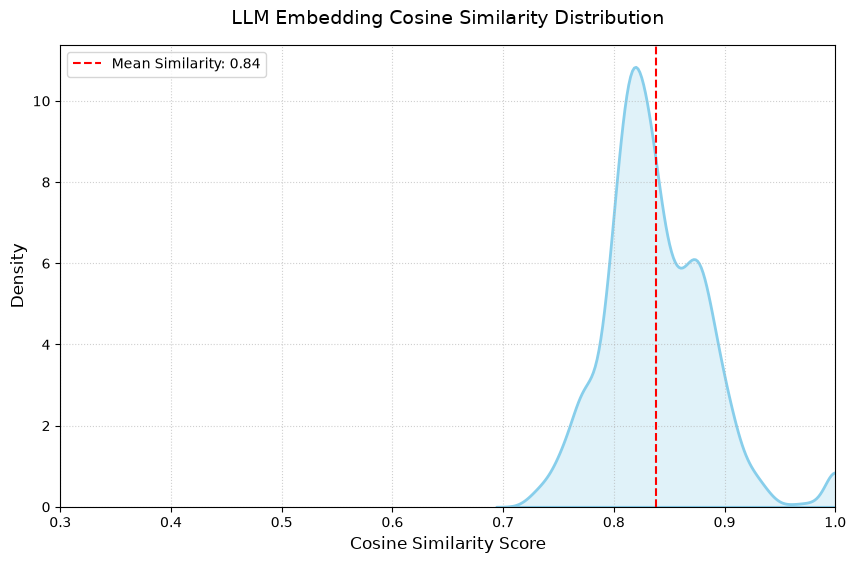

In [78]:
def plot_similarity_distribution(embeddings):

    #calculate the pairwise cosine similarity matrix
    similarity_matrix = cosine_similarity(embeddings)
    
    #extract the upper triangle to avoid self-similarity (1.0) and duplicates
    upper_tri_indices = np.triu_indices_from(similarity_matrix, k=1)
    similarity_scores = similarity_matrix[upper_tri_indices]
    
    #create the distribution plot
    plt.figure(figsize=(10, 6))
    sns.kdeplot(similarity_scores, fill=True, color="skyblue", linewidth=2)
    
    #add formatting and markers
    mean_score = np.mean(similarity_scores)
    plt.axvline(mean_score, color="red", linestyle="--", 
                label=f"Mean Similarity: {mean_score:.2f}")
    
    plt.title("LLM Embedding Cosine Similarity Distribution", fontsize=14, pad=15)
    plt.xlabel("Cosine Similarity Score", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.xlim(0.3, 1.0)  # standard bounds for anisotropic LLM spaces
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    
    plt.show()

plot_similarity_distribution(X_infloat)


## Cut-Off Point

- The Conservative elbow at ~0.95
    
    Guarantees near-zero noise
- The Aggresive elbow at ~0.85-0.87
    
    Balanced threshold, accepts some boarderline pairs while successfully rejecting the majority of noise to its left



## Re-Ranking After Starring


A candidate is starred if it:

* Ranks highly for the search query in ranked_e5
* Is classified as HR-related
* Has at least 90% classifier confidence
* Does not appear more than twice as a duplicate title
* Is among the top 10 remaining candidates


In [79]:
#good starring candidates: high query relevance, confirmed HR-related, and not buried in a large duplicate block
dupe_counts = data.groupby('job_title_clean')['job_title_clean'].transform('count')

starring_candidates = (
    ranked_e5
    .assign(
        dupe_count=dupe_counts, 
        hr_label=data['hr_label'], 
        hr_confidence=data['hr_confidence']
    )
    .loc[
        lambda df: 
            (df['hr_label'] == 'yes') & 
            (df['hr_confidence'] >= 0.9) & 
            (df['dupe_count'] <= 2)]
)
starred_indices = starring_candidates.head(10).index
print(starred_indices)


Index([2, 71, 5, 19, 50, 47, 73, 56, 74, 20], dtype='int64')


For every starred candidate, the code calculates:

* Similarity to the original query
* Similarity to that starred candidate

Using ALPHA = 0.5 so that both components hold equal weight

In [80]:
def rerank_with_starred(query, starred_indices, model, X, alpha=0.5, query_prefix="", normalize_embeddings=False):
    reranked_scores = [] #initialize the list to store combined scores for each starred candidate
    query_vec = model.encode([query_prefix + query], normalize_embeddings=normalize_embeddings)

    sim_to_query = cosine_similarity(query_vec, X)[0] #similarity to the original query

    for starred_index in starred_indices:
        starred_position = data.index.get_loc(starred_index)
        starred_vec = X[starred_position].reshape(1, -1) #reshape to 2D array for cosine similarity

        sim_to_starred = cosine_similarity(starred_vec, X)[0] #similarity to the starred candidate

        combined_score = (
            alpha * sim_to_query
            + (1 - alpha) * sim_to_starred
        )

        reranked_scores.append(combined_score) #append the combined score for this starred candidate

    average_score = np.mean(reranked_scores, axis=0) #compute the average score across all starred candidates
    return (
        data.assign(score=average_score)
        .sort_values('score', ascending=False)
        [['job_title_clean', 'location_clean', 'connection_clean', 'score']]
    )

ALPHA = 0.5

reranked_results = rerank_with_starred(query, starred_indices, infloat, X_infloat, ALPHA, query_prefix="query: ", normalize_embeddings=True)
reranked_results.head()


,job_title_clean,location_clean,connection_clean,score
2,aspiring human resources professional,raleighdurham north carolina area,44,0.936267
71,aspiring human resources professional,kokomo indiana area,71,0.936267
5,aspiring human resources specialist,greater new york city area,1,0.930125
47,aspiring human resources manager seeking inter...,houston texas area,7,0.919467
19,seeking human resources opportunities,chicago illinois,390,0.915503


In [81]:
# Remove candidates classified as irrelevant by the zero-shot model

reranked_results = (
    reranked_results
    .join(data[["hr_label", "hr_confidence"]])
    .loc[lambda df: df["hr_label"].eq("yes")]
    .drop(columns=["hr_label", "hr_confidence"])
    .reset_index(drop=True)
)

In [82]:
reranked_results.head(30)


,job_title_clean,location_clean,connection_clean,score
0,aspiring human resources professional,raleighdurham north carolina area,44,0.936267
1,aspiring human resources professional,kokomo indiana area,71,0.936267
2,aspiring human resources specialist,greater new york city area,1,0.930125
3,aspiring human resources manager seeking inter...,houston texas area,7,0.919467
4,seeking human resources opportunities,chicago illinois,390,0.915503
5,seeking human resources position,las vegas nevada area,48,0.912820
6,aspiring human resources professional passion...,new york new york,212,0.911688
7,aspiring human resources professional an ener...,austin texas area,174,0.908797
8,aspiring human resources management student se...,houston texas area,500,0.908162
9,aspiring human resources management student se...,houston texas area,500,0.908162


## Scoring

In [83]:
#manually adding labels for top 30 candidates after reranking
reranked_results["aspiring_hr"] = np.nan
reranked_results["hr_related"] = np.nan
aspiring_hr_labels = [1,1,1,1,1,
        1,1,1,1,1,
        0,0,1,1,1,
        1,1,1,1,1,
        1,1,1,0,0,
        0,0,0,0,1]
hr_related_labels = [1]*30
reranked_results.loc[reranked_results.index[:30], "aspiring_hr"] = aspiring_hr_labels
reranked_results.loc[reranked_results.index[:30], "hr_related"] = hr_related_labels
reranked_results[["job_title_clean","aspiring_hr", "hr_related"]].head(30)


,job_title_clean,aspiring_hr,hr_related
0,aspiring human resources professional,1.0,1.0
1,aspiring human resources professional,1.0,1.0
2,aspiring human resources specialist,1.0,1.0
3,aspiring human resources manager seeking inter...,1.0,1.0
4,seeking human resources opportunities,1.0,1.0
5,seeking human resources position,1.0,1.0
6,aspiring human resources professional passion...,1.0,1.0
7,aspiring human resources professional an ener...,1.0,1.0
8,aspiring human resources management student se...,1.0,1.0
9,aspiring human resources management student se...,1.0,1.0


On self evaluation of the top 30 candidates, 21 were aspiring HR & 28 aspiring/working in HR. 

The misslabeled candidates are:

1. A recruiter looking for aspiring HR professionals
2. A job-seeker looking for customer service or patient care roles

### NDCG@10

Measures two main things: 
1. how relevant an item is
2. how high up it appears on the list.

In [84]:
true_relevance = (
    reranked_results["aspiring_hr"]
    .dropna()
    .to_numpy()
    .reshape(1, -1)
)

predicted_scores = (
    reranked_results.loc[
        reranked_results["aspiring_hr"].notna(),
        "score"
    ]
    .to_numpy()
    .reshape(1, -1)
)

score_at_10 = ndcg_score(true_relevance, predicted_scores, k=10)
print(f"NDCG@10: {score_at_10:.4f}")

NDCG@10: 1.0000


NDCG@10 is 0.9364 because the first 10/10 rows are all labeled 1 for aspiring_hr.

### MAP (mean average precision)

In [85]:
map_aspiring_hr_score = average_precision_score(reranked_results['aspiring_hr'].iloc[:30], reranked_results['score'].iloc[:30])
map_hr_related_score = average_precision_score(reranked_results['hr_related'].iloc[:30], reranked_results['score'].iloc[:30])

print(f"Mean Average Precision (Aspiring HR): {map_aspiring_hr_score:.4f}")
print(f"Mean Average Precision (HR Related): {map_hr_related_score:.4f}")

Mean Average Precision (Aspiring HR): 0.9322
Mean Average Precision (HR Related): 1.0000


## MRR

In [86]:
def reciprocal_rank(labels):
    relevant_positions = np.flatnonzero(labels.to_numpy() == 1)

    if len(relevant_positions) == 0:
        return 0.0

    return 1 / (relevant_positions[0] + 1)


mrr_aspiring_hr = reciprocal_rank(reranked_results["aspiring_hr"].iloc[:30])
mrr_hr_related = reciprocal_rank(reranked_results["hr_related"].iloc[:30])

print(f"MRR (Aspiring HR): {mrr_aspiring_hr:.4f}")
print(f"MRR (HR Related): {mrr_hr_related:.4f}")

MRR (Aspiring HR): 1.0000
MRR (HR Related): 1.0000


MRR is 1 for both Aspiring HR and HR related candidates since the first result is 1.

## Precision@5

In [87]:
precision_5_aspiring_hr = reranked_results["aspiring_hr"].iloc[:5].eq(1).mean()
precision_5_hr_related = reranked_results["hr_related"].iloc[:5].eq(1).mean()

print(f"Precision@5 (Aspiring HR): {precision_5_aspiring_hr:.4f}")
print(f"Precision@5 (HR Related): {precision_5_hr_related:.4f}")

Precision@5 (Aspiring HR): 1.0000
Precision@5 (HR Related): 1.0000


## Precision@10

In [88]:
precision_10_aspiring_hr = reranked_results["aspiring_hr"].iloc[:10].mean()
precision_10_hr_related = reranked_results["hr_related"].iloc[:10].mean()

print(f"Precision@10 (Aspiring HR): {precision_10_aspiring_hr:.4f}")
print(f"Precision@10 (HR Related): {precision_10_hr_related:.4f}")

Precision@10 (Aspiring HR): 1.0000
Precision@10 (HR Related): 1.0000


All candidates except #10 are aspiring HR. Candidate #10 is already an HR professional. 

## Bias Check

In [89]:

bias_results = reranked_results.copy()

# Inspect values first
print(bias_results["location_clean"].value_counts(dropna=False).head(20))

location_clean
houston texas area                   7
denton texas                         6
san francisco bay area               5
greater philadelphia area            4
atlanta georgia                      4
izmir turkiye                        4
raleighdurham north carolina area    3
greater new york city area           2
austin texas area                    2
amerika birlesik devletleri          2
kokomo indiana area                  1
chicago illinois                     1
las vegas nevada area                1
new york new york                    1
cape girardeau missouri              1
jackson mississippi area             1
greater boston area                  1
monroe louisiana area                1
baton rouge louisiana area           1
virginia beach virginia              1
Name: count, dtype: int64


In [90]:
print(bias_results["connection_clean"].value_counts(dropna=False).head(20))

connection_clean
500    36
7       2
44      1
71      1
1       1
390     1
48      1
212     1
174     1
103     1
57      1
16      1
5       1
82      1
415     1
18      1
61      1
85      1
50      1
349     1
Name: count, dtype: int64


Most data points have 500+ connections

In [91]:
# Correlation between connection count and ranking score
connection_bias = bias_results[
    ["score","connection_clean"]
].dropna().corr(method="spearman").iloc[0, 1]

print(f"Spearman correlation with connection: {connection_bias:.3f}")

Spearman correlation with connection: -0.511


Low-Moderate correlation between score and number of connections

In [92]:
location_summary = (
    bias_results
    .groupby("location_clean", dropna=False)
    .agg(
        candidates=("score", "size"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        top_10_count=("score", lambda x: (x >= bias_results["score"].nlargest(10).min()).sum())
    )
    .sort_values("mean_score", ascending=False)
)

location_summary

,candidates,mean_score,median_score,top_10_count
location_clean,,,,
kokomo indiana area,1,0.936267,0.936267,1
chicago illinois,1,0.915503,0.915503,1
las vegas nevada area,1,0.912820,0.912820,1
new york new york,1,0.911688,0.911688,1
austin texas area,2,0.901110,0.901110,1
cape girardeau missouri,1,0.896861,0.896861,0
jackson mississippi area,1,0.895653,0.895653,0
greater new york city area,2,0.894436,0.894436,1
greater boston area,1,0.893018,0.893018,0


Interesting note that Houston texas has a lower overall score but 3 candidates in the top 10. This could be due to potentional duplicates with greater than 500 connections. We kept these ones in the dataset as we couldn't be positive that they were duplicate candidates.

It doesn't appear as if there is a large correlation between score and location/connections. This makes sense as I excluded these columns from embedding.


We could perform separate analysis on separate areas. Most likely recruiters will want candidates in their local area, unless they were hiring for a remote position. We would then look at if precision and recall remain similar across groups.
